# 02 · Modelling, evaluation & error analysis
All numbers below are read from files produced by `python -m aqforecast.train` (MLflow-tracked); nothing is hand-typed.

In [1]:
import json, pandas as pd, numpy as np
from aqforecast import config as C, aqi
m = json.loads((C.ARTIFACTS_DIR / "metrics.json").read_text())
pred = pd.read_parquet(C.PROCESSED_DIR / "test_predictions.parquet")
print("hold-out:", m["data"]["holdout_start"][:10], "→", m["data"]["end"][:10], "| rows:", m["data"]["holdout_rows_supervised"])
pd.DataFrame(m["holdout"]).T[["mae","rmse","wape_pct","bias","r2"]].round(3)

hold-out: 2025-09-26 → 2026-09-26 | rows: 209412


,mae,rmse,wape_pct,bias,r2
persistence,31.612,45.072,42.826,0.350,0.217
seasonal_naive_1d,24.667,35.756,33.418,-0.165,0.507
seasonal_naive_3d_mean,23.821,34.330,32.272,-0.261,0.546
lgbm,16.707,24.266,22.633,-0.258,0.773


### Baselines vs LightGBM on the hold-out year (all origins, all 72 horizons)

In [2]:
pd.DataFrame(m["holdout_shared_sample"]).T.drop("origins", errors="ignore")[["mae","rmse","wape_pct","r2"]].round(3)

,mae,rmse,wape_pct,r2
persistence,30.512,43.172,41.908,0.300
seasonal_naive_1d,23.602,34.466,32.416,0.554
seasonal_naive_3d_mean,23.075,33.641,31.693,0.575
lgbm,16.658,24.637,22.880,0.772
holt_winters,25.812,38.864,35.452,0.433


The table above is the shared random sample of origins where Holt-Winters (slow to refit) was also evaluated.

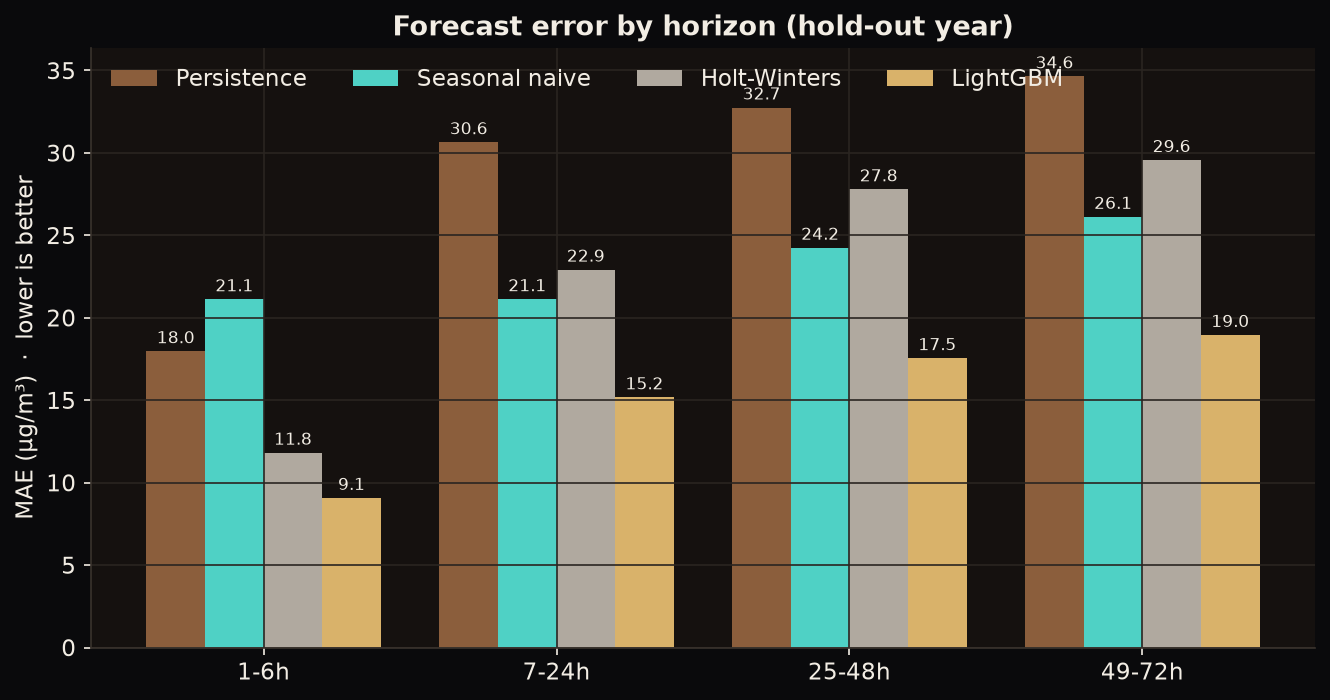

In [3]:
from IPython.display import Image
Image(str(C.FIGURES_DIR / "03_mae_by_horizon.png"))

### Hyper-parameter search (blocked time-series CV, before the hold-out year)

In [4]:
t = pd.DataFrame(m["cv"]["trials"])
t[["trial","n_estimators","learning_rate","num_leaves","min_child_samples","feature_fraction","lambda_l2","cv_mae"]].sort_values("cv_mae").round(3)

,trial,n_estimators,learning_rate,num_leaves,min_child_samples,feature_fraction,lambda_l2,cv_mae
7,7,500,0.05,15,50,0.7,10.0,16.827
4,4,600,0.03,31,50,0.9,1.0,16.906
0,0,400,0.05,31,200,0.7,1.0,16.953
2,2,600,0.03,15,200,0.5,0.0,16.953
5,5,500,0.05,31,50,0.9,10.0,16.955
1,1,300,0.05,63,200,0.7,1.0,17.003
6,6,500,0.05,31,400,0.7,1.0,17.097
8,8,300,0.05,63,400,0.5,1.0,17.100
3,3,500,0.05,63,200,0.9,10.0,17.110


### Smog season vs rest of year

In [5]:
pd.DataFrame(m["seasons"]).T[["mae","rmse","wape_pct","r2","n"]].round(3)

,mae,rmse,wape_pct,r2,n
smog_season_nov_feb,23.052,31.855,20.135,0.734,69120.0
rest_of_year,13.580,19.468,25.254,0.511,140292.0
snaive_smog_season,36.797,48.943,32.140,0.373,69120.0
snaive_rest_of_year,17.428,24.062,32.410,0.253,140292.0


### Alerts: 'Unhealthy or worse' (PM2.5 ≥ 55.5)

In [6]:
print(pd.DataFrame(m["alerts"]).round(3))
pd.DataFrame(m["alerts_by_horizon"]).round(3)

                       lgbm  seasonal_naive_3d_mean
alert_base_rate_pct  53.378                  53.378
alert_precision       0.856                   0.769
alert_recall          0.816                   0.802
alert_f1              0.835                   0.785
category_accuracy     0.642                   0.538
category_within_one   0.980                   0.939


,1-6h,7-24h,25-48h,49-72h
alert_base_rate_pct,53.274,53.273,53.395,53.465
alert_precision,0.927,0.870,0.848,0.834
alert_recall,0.903,0.843,0.797,0.793
alert_f1,0.915,0.856,0.821,0.813
category_accuracy,0.801,0.675,0.623,0.595
category_within_one,0.996,0.985,0.978,0.975


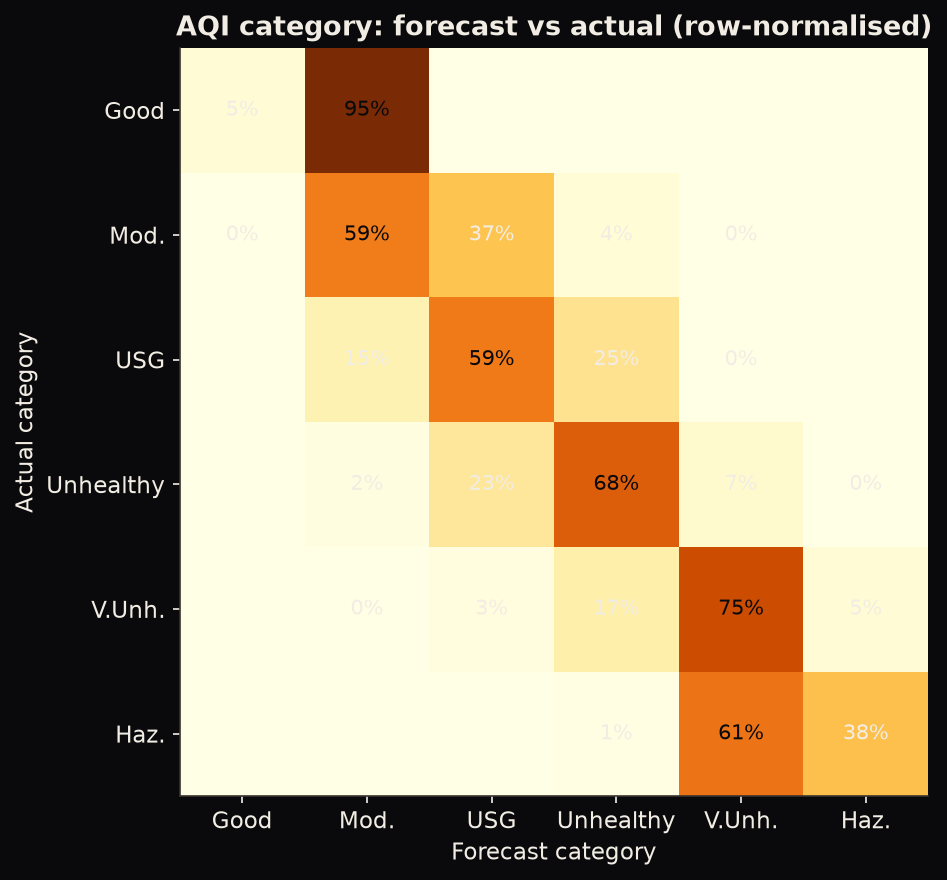

In [7]:
Image(str(C.FIGURES_DIR / "05_alert_confusion.png"))

### Prediction intervals

{
 "raw_80pct_band": {
  "coverage_pct": 70.29396596183601,
  "mean_width": 43.52219371996462
 },
 "cqr_80pct_band": {
  "coverage_pct": 84.80411819762,
  "mean_width": 56.610483950623724
 }
}
OOF CV coverage raw → conformal: 61.9 → 80.0


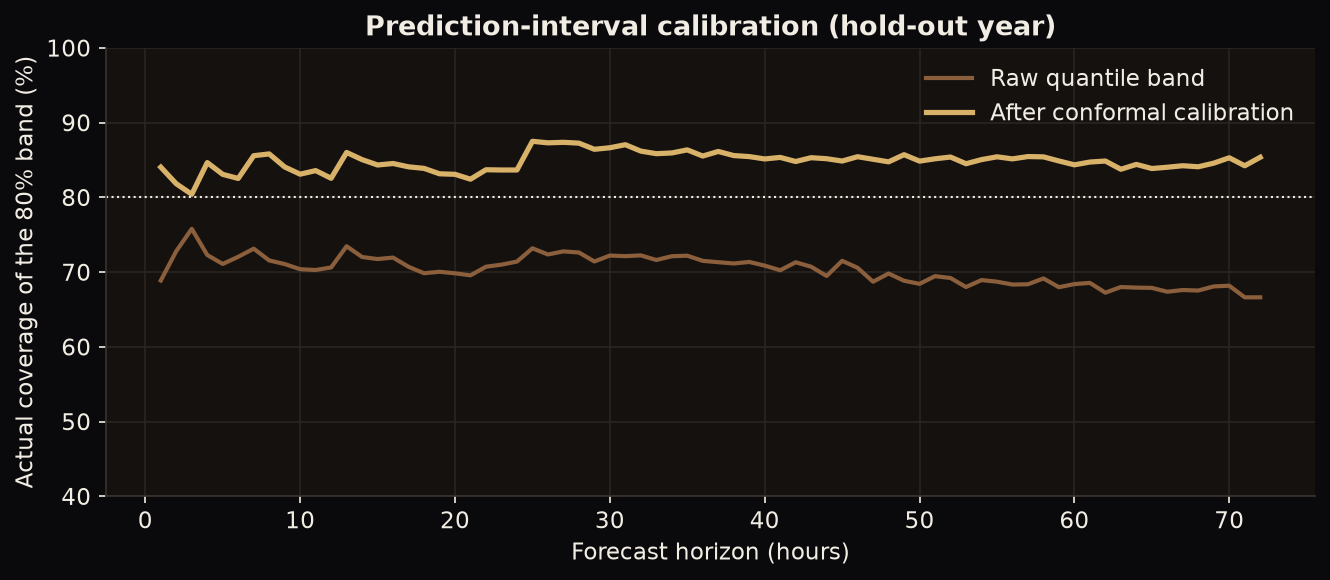

In [8]:
print(json.dumps(m["interval"], indent=1))
print("OOF CV coverage raw → conformal:", m["cv"]["oof_interval_raw"]["coverage_pct"].__round__(1), "→", m["cv"]["oof_interval_cqr"]["coverage_pct"].__round__(1))
Image(str(C.FIGURES_DIR / "06_interval_calibration.png"))

### Error analysis

In [9]:
p = pred.copy()
p["err"] = p.lgbm_q50 - p.y
p["abs"] = p.err.abs()
p["actual_cat"] = [aqi.CATEGORIES[i] for i in aqi.category_index(p.y)]
print("Where does the model miss? bias and MAE by actual AQI category")
p.groupby("actual_cat").agg(n=("y","size"), bias=("err","mean"), mae=("abs","mean")).round(1).reindex(aqi.CATEGORIES)

Where does the model miss? bias and MAE by actual AQI category


,n,bias,mae
actual_cat,,,
Good,360,11.4,11.5
Moderate,43880,9.1,10.4
Unhealthy for Sensitive Groups,53393,2.8,10.0
Unhealthy,81635,-4.4,18.8
Very Unhealthy,26184,-2.3,28.9
Hazardous,3960,-48.0,53.7


In [10]:
print("By hour of day of the target")
p.groupby(p.target_time.dt.hour).abs.mean().round(1).to_frame("MAE").T

By hour of day of the target


target_time,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
MAE,19.7,20.2,20.0,19.5,19.6,19.9,18.9,19.7,19.3,17.3,...,11.6,10.8,11.9,13.9,13.6,14.8,16.3,17.9,19.2,20.0


In [11]:
print("Worst 5 origin-days (24h-ahead) - candidates for a post-mortem")
w = p[p.horizon == 24].groupby(p.origin.dt.date).abs.mean().sort_values(ascending=False).head(5).round(1)
w.to_frame("MAE")

Worst 5 origin-days (24h-ahead) - candidates for a post-mortem


,MAE
origin,
2026-06-30,82.2
2026-05-28,66.8
2026-01-18,66.2
2025-11-23,57.0
2026-05-29,55.4


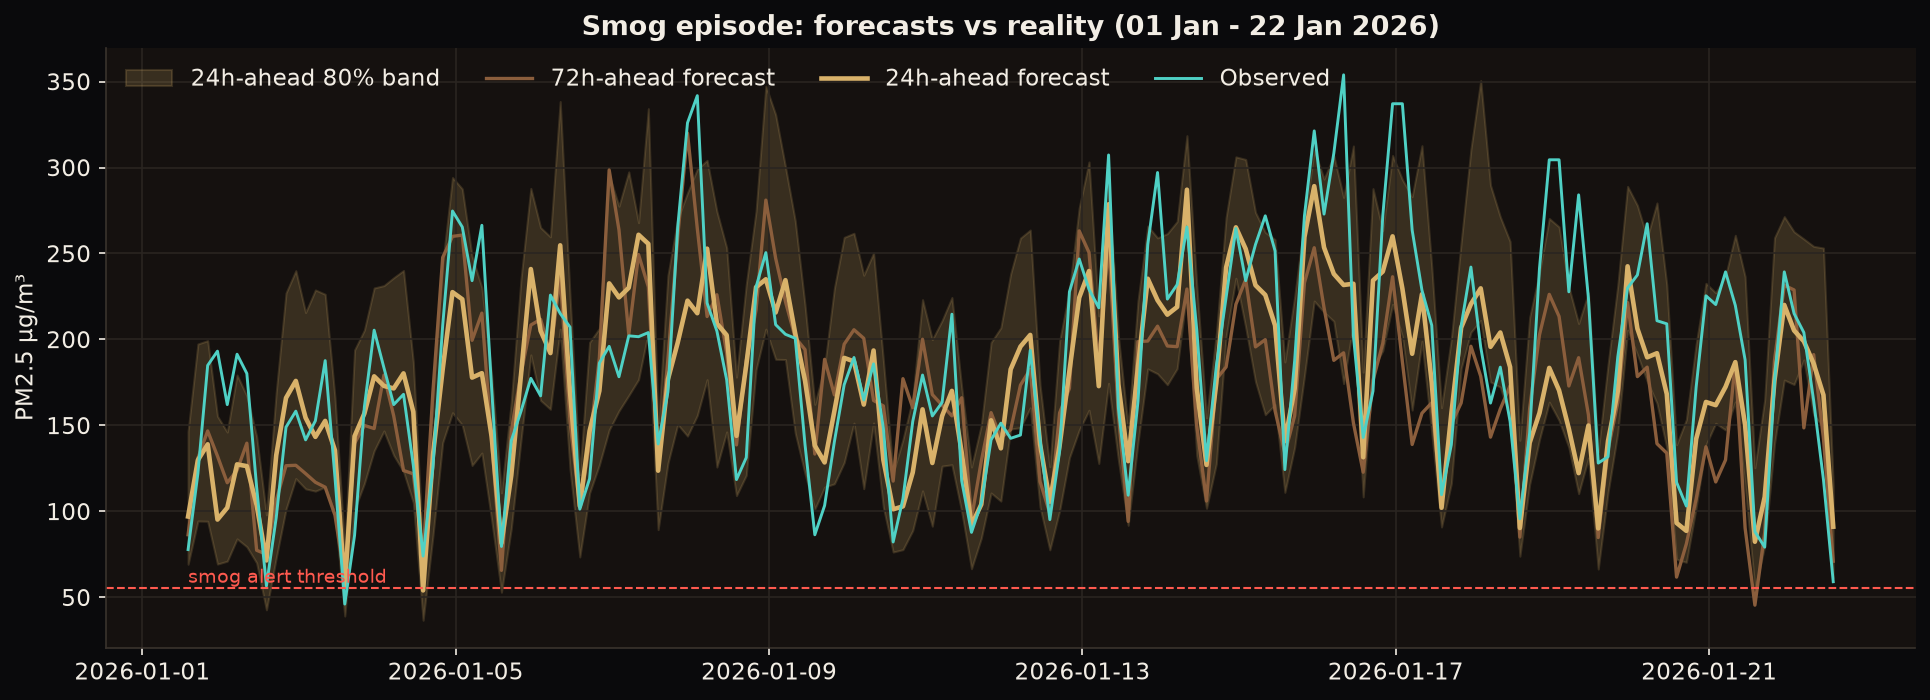

In [12]:
Image(str(C.FIGURES_DIR / "04_smog_episode.png"))

### Explainability (SHAP, 13-24 h-ahead median model)

{
 "pm25_now": 0.1239,
 "pm25_trend6": 0.0705,
 "wind_mean_h": 0.068,
 "boundary_layer_height_tgt": 0.0626,
 "pm_coarse_ratio": 0.0558,
 "blh_diff_tgt": 0.0539,
 "snaive_1d": 0.0418,
 "pm10_now": 0.0409,
 "nitrogen_dioxide_now": 0.0281,
 "temp_diff_tgt": 0.0278,
 "snaive_3d_mean": 0.0274,
 "relative_humidity_2m_tgt": 0.0269,
 "wind_v_tgt": 0.0265,
 "pm25_lag1": 0.0265,
 "wind_speed_10m_tgt": 0.0232
}


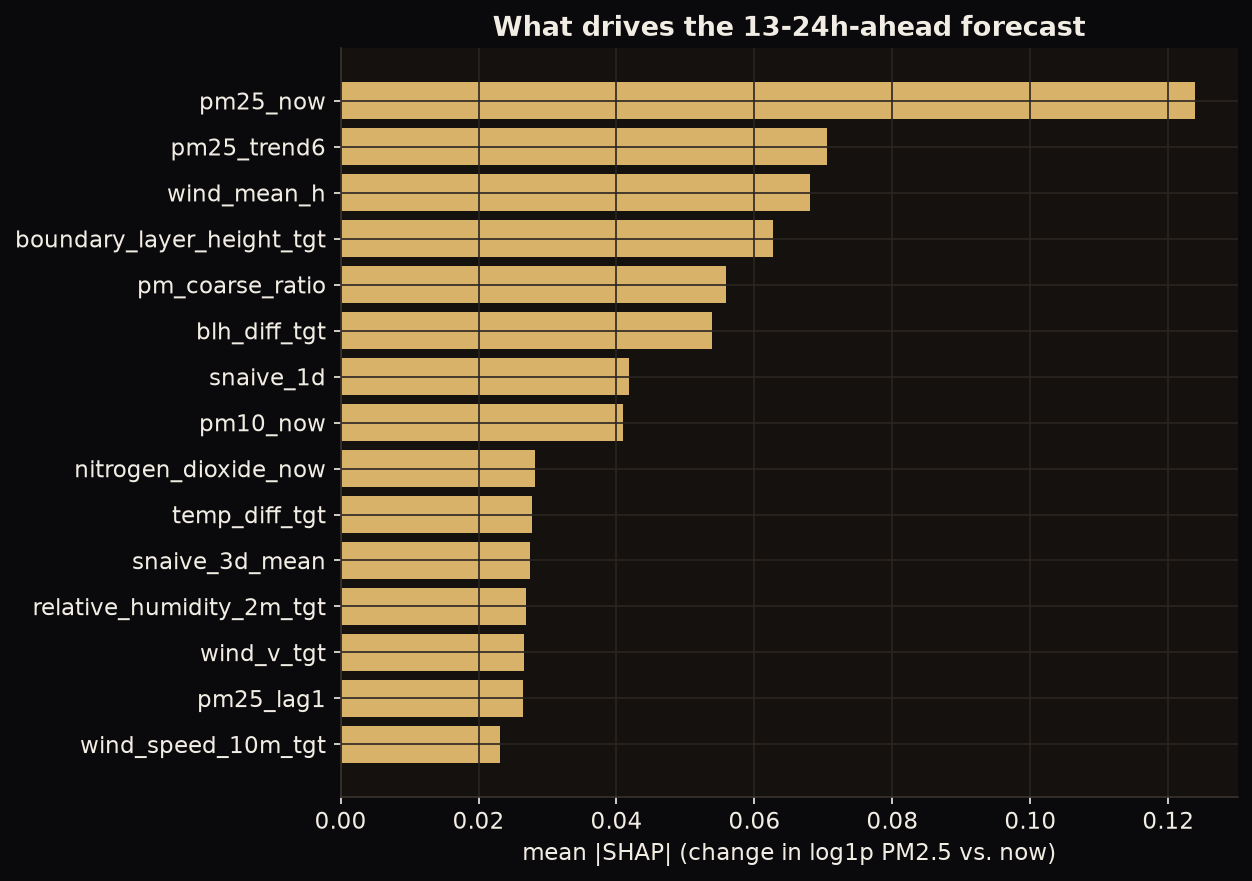

In [13]:
print(json.dumps(json.loads((C.ARTIFACTS_DIR / "shap_top.json").read_text()), indent=1))
Image(str(C.FIGURES_DIR / "07_shap_importance.png"))